In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="glm-5",
#     model="qwen3.5-plus",
#     model="kimi-k2.5",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

D:\Anaconda\envs\taidibei\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
import re
import pdfplumber
from langchain_core.documents import Document

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)  
    text = re.sub(r'\n{3,}', '\n\n', text)  
    return text.strip()

In [4]:
from langchain_community.document_loaders import PDFPlumberLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

pdf_folder = r"示例数据\附件5：研报数据"
docs = []

for file_name in os.listdir(pdf_folder):
    file_path = os.path.join(pdf_folder, file_name)
    
    if os.path.isdir(file_path):
        
        for pdf_name in os.listdir(file_path):
            pdf_path = os.path.join(file_path, pdf_name)
            
            loader = PyMuPDFLoader(pdf_path)
            docs.extend(loader.load())

            
print(docs[0].page_content)
print("-"*100)
print(docs[0].metadata)
        
for doc in docs:
    doc.page_content = clean_text(doc.page_content)

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1500, chunk_overlap=500
)

doc_splits = text_splitter.split_documents(docs)

请务必阅读正文后的重要声明部分 
 
1 
2025 年10 月29 日 
证券研究报告•2025 年三季报点评 
买入 （维持） 
 
当前价： 28.94 元 
华润三九（000999） 医药生物 
目标价： ——元（6 个月） 
内涵+外延双轮驱动，经营拐点已现 
投资要点 
西南证券研究院 
分析师：杜向阳 
执业证号：S1250520030002 
电话：021-68416017 
邮箱：duxy@swsc.com.cn 
联系人：王钰玮 
电话：021-68415819 
邮箱：wangyuwei@swsc.com.cn 
相对指数表现 
数据来源：聚源数据 
基础数据 
总股本(亿股) 
16.64 
流通A 股(亿股) 
16.63 
52 周内股价区间(元) 
27.30-37.35 
总市值(亿元) 
481.64 
总资产(亿元) 
386.98 
每股净资产(元) 
11.12 
相关研究 
1. 华润三九（000999）：业绩稳健增长，并
购整合持续推进  (2025-03-19) 
 
 事件：公司发布2025 年三季报。2025 年前三季度，公司实现营业收入219.9
亿元，同比+11.4%；归母净利润23.5 亿元，同比-20.5%；扣非归母净利润
为21.9 亿元，同比-20.6%。2025 年Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿
元，分别同比-6%/+16.8%/+27.4%；归母净利润12.7/5.5/5.4 亿元，分别同
比-6.9%/-47.3%/-4.3%；扣非归母净利润12.2/4.8/4.9 亿元，分别同比
-8.3%/-51.1%/+10.1%，业绩符合预期。 
 内生业务环比增长，处方药逐步恢复。2025 年前三季度，公司实现营业收
入219.9 亿元，同比+11.4%；Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿元，分
别同比-6%/+16.8%/+27.4%，其中内生业务三季度环比增长。1）CHC 领域，
呼吸品类受去年高基数与今年呼吸道疾病发病率回落影响，零售渠道自去年
年底起受政策影响呈阶段性调整。2）处方药已较好消化集采影响，逐步恢
复。天士力以处方药为核心，已完成百日融合，预计持续赋能。3）并表公
司昆药集团2025 前三季度营收显著下滑对公司收入产生影响。 


In [5]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 64,      # 视显存调整：16/32/64
        "show_progress_bar": True,
    },
)

vectorstore = Milvus.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs",
    drop_old=True,
)

C:\Users\cr\AppData\Local\Temp\ipykernel_40924\3288711727.py:5: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(
C:\Users\cr\AppData\Local\Temp\ipykernel_40924\3288711727.py:5: LangChainDeprecationWarning: `encode_kwargs['show_progress_bar']` was deprecated in LangChain 0.2.5 and will be removed in 1.0. Use the show_progress method on HuggingFaceBgeEmbeddings instead.
  embeddings = HuggingFaceBgeEmbeddings(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = Milvus(
    embedding_function=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs",
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

texts = retriever.invoke("国家医保目录新增的中药产品有哪些")

for text in texts:
    print(text.page_content)
    print("-" * 50)

行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
药物能够有效提升在患者中的渗透率。 
图表7：凭借商保，较高定价的药物能够实现患者渗透率的快速提升 
 
来源：insight，国金证券研究所 
中药经典名方申请较多，但政策鼓励创新方向明确。根据国家医保局25 年8 月公告，通过初步审查的中成药共23 种、
合计25 个产品。今日公示名单，最终入选7 个产品，包括4 个1 类新药以及3 个3 类新药。本次整体入选比例不高，
主要系经典名方申请较多，且多数未入选。通过初审名单中，共6 个1 类新药，最终入选4 个。12 个3 类中药，最终
入选3 个。6 个进口中药，无入选。1 个天然药物1.1 类，未入选。 
图表8：2025 年国家医保目录新增7 个中药产品 
 
来源：国家医保局，国金证券研究所 
投资建议 
西药：建议关注纳入新版医保目录创新药较多/品种重磅的恒瑞医药、百济神州、康方生物、科伦博泰、信达生物等，
以及大单品首次纳入医保的康诺亚（IL4 单抗）、特宝生物（长效生长激素）等。 
中成药：建议关注入选新版医保目录的中药产品放量潜力，如华润三九的益气清肺颗粒、以岭药业的芪防鼻通片、方
盛制药的养血祛风止痛颗粒、康缘药业的玉女煎颗粒/温阳解毒颗粒等。 
序号
公司
药品
2025年医保目录价格
2025年医保目录适应症
用法用量
注册分类
1
华润三九
益气清肺颗粒
13.60元(每袋装15g(相当
于饮片52g))
益气养阴，健脾和中，清热祛湿。适用于疫病后短期症状，
气阴两虚，脾虚失运，余邪未尽证，症见倦怠乏力、动后气
短、干咳少痰、咽喉不利、胃脘痞闷、纳呆便溏，舌淡或红
、少津，脉细数。
温水冲服。1次1袋，1
日2次。疗程14天。
中药3.2类
2
以岭药业
芪防鼻通片
--------------------------------------------------
行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
 
凭借相关药物的医保准入，有望实现产品放量与市场份额的快速提升。本轮医保谈判中西药涉及的107 个品类，
合计116 款药物（部分同一品类有多家药企入选）。其中恒瑞医药合计11 款新药首次纳入医保目录，其次是阿斯
利康合计纳入4 款，正大天晴、科伦博泰、礼来制药、齐鲁制药、罗氏制药则分别成功纳入3 款药

In [7]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_pdf_file",
    "Search and return information from the internal knowledge base.",
) 

In [8]:
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

engine = create_engine("sqlite:///example.db")

###
sheets = pd.read_excel(
    r"示例数据\附件2：财务报告\深交extract_result.xlsx",
    sheet_name=None,
    engine="openpyxl"
)
###

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [9]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
import json

In [10]:
def merge_dict(a, b):
    a = a or {}
    b = b or {}
    out = dict(a)
    out.update(b)
    return out

def merge_list(a, b):
    return (a or []) + (b or [])

In [11]:
from typing_extensions import TypedDict, Required
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal, Annotated
from pydantic import BaseModel, Field
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class SubTask(BaseModel):
    task_id: str
    type: Literal["sql", "rag", "synthesis", "clarify"]
    goal: str
    priority: int = Field(default=5, ge=1, le=10)
    depends_on: List[str] = Field(default_factory=list)
    status: Literal["pending", "ready", "running", "done", "failed"] = "pending"

class ParentState(MessagesState, total=False):
    query: Required[str]
        
    real_query: str

    reason: str
    missing_slots: List[str] = []
        
    task_plan: List[dict]
    
    task_results: Annotated[Dict[str, dict], merge_dict]
    execution_trace: Annotated[List[dict], merge_list]
        
    current_task_id: str
    schedule_status: Literal["all_done", "blocked", "has_task"]

    final_answer: str
    summary: str
        
    sql_messages: Annotated[list[AnyMessage], add_messages]
        
    image_path: List[str]
    references: List[dict]
    last_sql_query: str
        
    question_count: int
    skip_summary: bool
        
class PlanDecision(BaseModel):
    reason: str
    missing_slots: List[str] = Field(default_factory=list)
    tasks: List[SubTask] = Field(default_factory=list)

In [12]:
def merge_query(state: ParentState):
    query = state.get("query") or state["messages"][-1].content
    summary = state.get("summary", "")
    
    if summary == "":
        return {
        "real_query": query,
        }
    
    prompt = f"""
    
你是一个对话查询改写助手。你的任务是根据“历史对话摘要 summary”和“用户当前输入 query”，判断用户这一轮真正想问的问题，并输出一个完整、明确、可独立理解的 query。

请严格遵循以下规则：

1. 如果当前 query 本身已经完整明确，不依赖历史上下文，就直接原样返回，不要过度改写。
2. 如果当前 query 中出现了代词、指代、省略、延续上文的表达（例如“它”“这个”“刚才那个”“继续”“再详细一点”“那数据库里的呢”），就结合 summary 补全成一个完整明确的问题。
3. 改写后的 query 必须保留用户原本意图，不能擅自增加新需求，也不能改变问题方向。
4. 优先补全以下信息：
   - 当前问的是哪个对象
   - 当前问的是哪个任务/主题
   - 是否是在上一轮结果基础上继续追问
   - 是否有输出格式、范围、限制条件
5. 如果 summary 与当前 query 无明显关系，则以当前 query 为准。
6. 输出必须简洁，只输出“最终 query”本身，不要输出解释，不要输出分析过程，不要加引号。

历史对话摘要 summary：
{summary if summary else "（无历史摘要）"}

用户当前输入 query：
{query}

请输出用户这一轮真正的完整 query：
    
    """
    
    real_query = llm.invoke([{"role": "user", "content": prompt}]).content.strip()
    
    return {
        "real_query": real_query,
    }

In [13]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema", messages_key="sql_messages")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query", messages_key="sql_messages")

In [14]:
def list_tables(state: ParentState):
    query = state["real_query"]
    
    prompt = f"""
    
你需要为后续 SQL 查询选择最相关的表，并调用 sql_db_schema 获取 schema。

要求：
1. 只调用 sql_db_schema
2. 选择最相关的 1~3 张表
3. 不要直接回答用户问题

当前问题：{query}

"""
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke([HumanMessage(content=prompt)])

    return {"sql_messages": [response]}

generate_query_system_prompt = """
你是一个专为与 SQL 数据库交互而设计的智能体。
给定一个用户输入问题，请生成一条语法正确的 {dialect} 查询语句并执行，
然后查看查询结果并返回答案。除非用户明确指定了希望获取的示例数量，否则始终将你的查询结果限制在最多 {top_k} 条。

你可以按相关列对结果进行排序，以返回数据库中最有趣的示例。切勿查询特定表的所有列，仅根据问题请求相关的列。

对于趋势/可视化类问题（例如：趋势、变化、走势、近几年、历年、可视化、绘图、折线图、柱状图）：
- 返回时间序列查询，而非单个标量结果
- 选择一个时间周期列和一个数值指标列
- 尽可能将它们分别别名为 x_axis 和 y_axis
- 按时间顺序升序排列结果
- 不要机械地应用默认的 top_k 限制；应保留绘图所需的所有时间段
- 不要输出任何 Python / matplotlib / pyecharts / SQL 以外的代码
- 不要输出 ```python 代码块
- 只负责返回查询结果和数据解读
- 图表由系统后处理函数自动生成，不由你在文本中生成

切勿对数据库执行任何 DML 语句（如 INSERT、UPDATE、DELETE、DROP 等）。

如果上下文中已经给出了所需表的 schema，请不要再次调用 sql_db_schema。
此阶段只允许两种行为：
1. 生成并调用 sql_db_query；
2. 在已有查询结果时直接输出最终答案。
""".format(
    dialect=db.dialect,
    top_k=5,
)

def generate_query(state: ParentState):
    query = state["real_query"]
    
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt + f"""

            补充上下文：
            - 用户输入问题：{query}
    
            """
    }
    
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["sql_messages"])

    return {"sql_messages": [response]}


check_query_system_prompt = """
你是一位注重细节的 SQL 专家。

请仔细检查 {dialect} 查询中是否存在以下常见错误：
- 在涉及 NULL 值时使用 NOT IN
- 应使用 UNION ALL 时却使用了 UNION
- 使用 BETWEEN 处理开区间（排他性范围）
- 谓词中的数据类型不匹配
- 标识符引用未正确加引号
- 函数使用的参数数量不正确
- 未转换为正确的数据类型
- 连接（JOIN）时使用了错误的列

如果发现上述任何错误，请重写查询语句；如果没有错误，则直接复现原始查询。

完成此检查后，你将调用相应的工具来执行查询。
""".format(dialect=db.dialect)

def check_query(state: ParentState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    tool_call = state["sql_messages"][-1].tool_calls[0]
    tool_name = tool_call.get("name")

    if tool_name != "sql_db_query":
        raise ValueError(f"check_query 只应处理 sql_db_query，当前收到: {tool_call}")

    args = tool_call.get("args", {}) or {}
    sql_text = args if isinstance(args, str) else (
        args.get("query") or
        args.get("__arg1") or
        args.get("input") or
        args.get("sql")
    )

    if not sql_text:
        raise ValueError(f"sql_db_query 的参数结构异常: {tool_call}")

    user_message = {"role": "user", "content": sql_text}

    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["sql_messages"][-1].id

    return {"sql_messages": [response]}

In [15]:
def extract_table_names_from_tool_call(tool_call):
    args = tool_call.get("args", {}) or {}
    table_names = args.get("table_names") or args.get("__arg1") or []

    if isinstance(table_names, str):
        table_names = table_names.replace("，", ",")
        table_names = [x.strip() for x in table_names.split(",") if x.strip()]

    if table_names is None:
        table_names = []

    return table_names


def should_continue(state: ParentState) -> Literal["check_query", "get_schema", END]:
    last_message = state["sql_messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []

    if not tool_calls:
        return END

    tool_call = tool_calls[0]
    tool_name = tool_call.get("name")

    if tool_name == "sql_db_query":
        return "check_query"

    if tool_name == "sql_db_schema":
        table_names = extract_table_names_from_tool_call(tool_call)
        if table_names:
            return "get_schema"

        print(f"[warn] sql_db_schema 的 table_names 为空: {tool_call}")
        return END

    print(f"[warn] generate_query 返回了未预期的工具调用: {tool_calls}")
    return END

builder = StateGraph(ParentState)
builder.add_node(list_tables)
# builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
# builder.add_edge("list_tables", "call_get_schema")
# builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("list_tables", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
    {
        "check_query": "check_query",
        "get_schema": "get_schema",
        END: END,
    },
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()

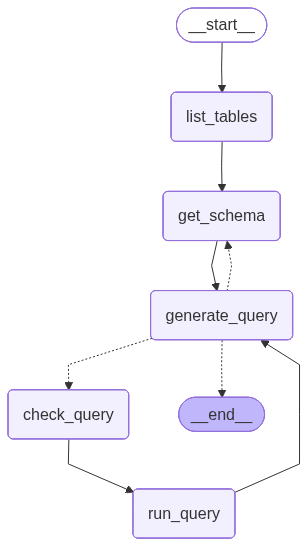

In [16]:
from IPython.display import Image, display

display(Image(sql_graph.get_graph().draw_mermaid_png()))

In [17]:
def format_messages_as_text(messages):
    lines = []

    for msg in messages:
        if isinstance(msg, dict):
            role = msg.get("role", "unknown")
            content = msg.get("content", "")
        else:
            msg_type = getattr(msg, "type", "unknown")
            content = getattr(msg, "content", "")

            if msg_type == "human":
                role = "user"
            elif msg_type == "ai":
                role = "assistant"
            else:
                role = msg_type

        lines.append(f"{role}: {content}")

    return "\n".join(lines)

def summarize(state: ParentState):
    if state.get("skip_summary", False):
        return {}
    
    messages = state.get("messages", [])
    latest_turn = messages[-2:] if len(messages) >= 2 else messages
    latest_turn_text = format_messages_as_text(latest_turn)
    old_summary = state.get("summary", "")
    
    summarize_prompt = f"""
    
        你是一个负责维护多轮对话记忆的模块。
        
        请基于【历史记忆】和【最新对话】，更新记忆。
        只保留对后续任务推进有价值的信息。
        
        记忆中只保留：
        - 用户当前目标
        - 已确认的关键信息
        - 用户偏好与限制
        - 尚未解决的问题
        - 下一步应做的事

        请遵守：
        - 不要复述原始对话
        - 不要保留寒暄、客套、重复内容
        - 若新旧信息冲突，以最新且明确确认的信息为准
        - 未确认内容单独标注，不要当作事实
        - 删除过时信息
        - 不要编造任何未出现的信息
        - 回答最多使用五句话，并保持简洁。

        【历史信息】
        {old_summary}

        【最新对话】
        {latest_turn_text}
        
    """
    
    summarize_history = llm.invoke([{"role": "user", "content": summarize_prompt}]).content.strip()
    
    print("-"*100)
    print("Summary")
    print(summarize_history)
    print("-"*100)
    
    return {
        "summary": summarize_history,
    }

In [18]:
import json
import re
from pydantic import ValidationError

VALID_TASK_TYPES = {"sql", "rag", "clarify", "synthesis"}
VALID_STATUS = {"pending", "ready", "running", "done", "failed"}

def extract_json_object(text: str) -> str:
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?", "", text).strip()
        text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{[\s\S]*\}", text)
    if not match:
        raise ValueError("planner 输出中未找到合法 JSON 对象")

    return match.group(0)


def normalize_plan_data(data: dict) -> dict:
    data = dict(data or {})
    data.setdefault("reason", "")
    data.setdefault("missing_slots", [])
    data.setdefault("tasks", [])

    tasks = data.get("tasks", [])
    normalized_tasks = []
    seen_task_ids = []

    for i, task in enumerate(tasks, start=1):
        task = dict(task or {})

        task_id = str(task.get("task_id") or f"task_{i}")
        task_type = str(task.get("type") or "clarify")
        if task_type not in VALID_TASK_TYPES:
            task_type = "clarify"

        goal = str(task.get("goal") or "").strip()
        if not goal:
            goal = f"执行{task_type}任务"

        try:
            priority = int(task.get("priority", i))
        except Exception:
            priority = i
        priority = max(1, min(priority, 10))

        depends_on = task.get("depends_on", [])
        if not isinstance(depends_on, list):
            depends_on = []

        # 只保留已经出现过的 task_id，避免非法依赖
        depends_on = [d for d in depends_on if d in seen_task_ids]

        status = str(task.get("status") or "pending")
        if status not in VALID_STATUS:
            status = "pending"

        normalized_tasks.append({
            "task_id": task_id,
            "type": task_type,
            "goal": goal,
            "priority": priority,
            "depends_on": depends_on,
            "status": status,
        })
        seen_task_ids.append(task_id)

    # 自动补 synthesis：
    # 若存在多个执行任务(sql/rag)，且没有 clarify，且没生成 synthesis，则自动补一个
    exec_task_ids = [t["task_id"] for t in normalized_tasks if t["type"] in {"sql", "rag"}]
    has_clarify = any(t["type"] == "clarify" for t in normalized_tasks)
    has_synthesis = any(t["type"] == "synthesis" for t in normalized_tasks)

    if len(exec_task_ids) >= 2 and (not has_clarify) and (not has_synthesis):
        normalized_tasks.append({
            "task_id": f"task_{len(normalized_tasks) + 1}",
            "type": "synthesis",
            "goal": "整合前置任务结果，生成统一答复",
            "priority": min(10, len(normalized_tasks) + 1),
            "depends_on": exec_task_ids,
            "status": "pending",
        })

    data["tasks"] = normalized_tasks
    return data


def fallback_plan(question: str, err: Exception) -> PlanDecision:
    return PlanDecision(
        reason=f"planner 调用或解析失败：{err}",
        missing_slots=["period"],
        tasks=[
            SubTask(
                task_id="task_1",
                type="clarify",
                goal="询问用户想查询的时间范围",
                priority=1,
                depends_on=[],
                status="pending",
            )
        ],
    )

In [19]:
def plan_node(state: ParentState):
    question = state["real_query"]


    route_prompt = f"""
你是上市公司财报智能问数系统的任务规划器（Planner）。

你的任务不是直接回答用户问题，而是：
1. 识别用户问题中的一个或多个核心意图；
2. 先在内部判断该问题整体更接近 sql / rag / hybrid / clarify；
3. 再将问题拆解为可执行 tasks；
4. 输出可直接进入调度器的 JSON。

你只能使用以下 task type：
- sql：适用于可以主要通过结构化财务数据库回答的问题，如数值查询、指标查询、同比/环比、趋势、排名、topN、筛选、排序、聚合统计、跨公司比较、可视化所需时间序列数据
- rag：适用于需要主要依赖非结构化文本知识库回答的问题，如原因分析、政策解读、研报观点、公告理解、行业判断、风险分析、管理层表述、市场预期
- clarify：适用于用户问题缺少关键条件，当前无法可靠执行
- synthesis：适用于同时存在多个执行任务时，对前置任务结果进行整合，形成统一答复

内部判定原则（非常重要）：
- 如果问题主要在问“多少、是否、排名、变化趋势、同比环比、topN、哪个最大/最小”，优先视为 sql
- 如果问题主要在问“为什么、原因、影响、怎么看、风险、政策、研报怎么说”，优先视为 rag
- 如果问题同时包含“查数据 + 做解释/归因/结合研报”，视为 hybrid
- 如果问题缺少关键查询条件，视为 clarify

请特别注意：
- 不要因为问题里出现“分析”两个字就一律归为 rag
- “趋势分析”“同比分析”“排名分析”“变化趋势”通常仍然属于 sql
- “原因分析”“政策影响分析”“研报观点分析”通常属于 rag
- “数据趋势 + 原因解释”属于 hybrid
- 若问题中有多个子任务，先判断每个子任务分别依赖结构化数据还是非结构化文本；只有同时存在至少一个 sql 子任务和至少一个 rag 子任务时，才应规划为混合多任务
- 对趋势/走势/变化/历年/可视化类问题，只要已经给出相对时间范围，就不要因为 period 再发 clarify

时间范围判定规则（非常重要）：
以下表达都视为已提供有效时间范围：
- 近几年
- 最近几年
- 近年来
- 近三年 / 近五年 / 过去三年 / 过去五年
- 历年 / 近年
- 最近几个报告期

例如：
- “华润三九近几年的每股收益变化趋势”
- “比亚迪近三年营收走势”
- “近年来净利润波动情况”
这些都应直接规划为 sql，不要再追问 period。

槽位缺失判断：
- company：公司名
- period：报告期/时间范围
- metric：指标名
- compare_target：比较对象
- explanation_target：待解释对象

clarify 触发原则：
- 缺少公司名，且无法从上下文确定
- 缺少指标名，且无法执行
- 完全缺少时间范围，且该问题明显依赖报告期
- 比较类问题缺少比较对象
- 原因解释类问题缺少待解释对象

任务规划规则：
1. 若问题包含多个核心意图，必须拆成多个 tasks
2. 若任务之间有前后依赖，必须写入 depends_on
3. priority 越小优先级越高
4. status 初始统一为 "pending"
5. 若存在多个执行任务(sql/rag)，通常最后要有 synthesis 任务
6. task_id 必须唯一，如 task_1, task_2, task_3
7. depends_on 只能引用前面已经出现的 task_id
8. 若整体属于 clarify，通常只输出一个 clarify task
9. 若整体本质是单一 sql 或单一 rag，就不要为了形式额外生成 synthesis

输出要求：
1. 只能输出 JSON
2. 不要输出 markdown 代码块
3. 不要输出额外解释
4. 最终只输出以下字段：reason、missing_slots、tasks

输出格式：
{{
  "reason": "为什么这样规划",
  "missing_slots": ["缺失槽位1", "缺失槽位2"],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql | rag | clarify | synthesis",
      "goal": "子任务目标",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例1：
用户问题：比亚迪2025年三季度营业收入是多少？
输出：
{{
  "reason": "这是明确的单指标单时期数值查询，主要依赖结构化财务数据库",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询比亚迪2025年三季度营业收入",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例2：
用户问题：金花股份近几年的利润总额变化趋势是什么样的？
输出：
{{
  "reason": "这是时间序列趋势分析问题，且“近几年”已提供有效时间范围，主要依赖结构化财务数据",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询金花股份近几年的利润总额时间序列数据，用于分析变化趋势",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例3：
用户问题：国家医保目录新增的中药产品有哪些？
输出：
{{
  "reason": "这是知识检索类问题，需要依赖政策文件或研报等非结构化文本知识库",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "rag",
      "goal": "检索医保目录与相关资料中新增中药产品信息",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例4：
用户问题：华润三九近三年的主营业务收入情况做可视化绘图，主营业务收入上升的原因是什么？
输出：
{{
  "reason": "前半部分需要结构化财务数据做趋势分析和可视化，后半部分需要非结构化文本证据做原因解释，因此应拆分为混合多任务",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询华润三九近三年主营业务收入时间序列数据，并用于可视化绘图",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }},
    {{
      "task_id": "task_2",
      "type": "rag",
      "goal": "检索华润三九主营业务收入上升原因的公告、年报或研报证据",
      "priority": 2,
      "depends_on": ["task_1"],
      "status": "pending"
    }},
    {{
      "task_id": "task_3",
      "type": "synthesis",
      "goal": "整合主营业务收入趋势结果、可视化结果与原因解释，形成统一答复",
      "priority": 3,
      "depends_on": ["task_1", "task_2"],
      "status": "pending"
    }}
  ]
}}

示例5：
用户问题：利润总额是多少？
输出：
{{
  "reason": "缺少公司和报告期，无法可靠执行查询",
  "missing_slots": ["company", "period"],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "clarify",
      "goal": "向用户确认公司名称和报告期，以继续查询利润总额",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例6：
用户问题：华为每股收益是多少？
输出：
{{
  "reason": "缺少报告期，无法直接执行查询",
  "missing_slots": ["period"],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "clarify",
      "goal": "向用户确认报告期，以继续查询每股收益",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例7：
用户问题：华润三九近几年的每股收益的变化趋势
输出：
{{
  "reason": "这是趋势分析问题，且“近几年”已提供有效时间范围，可直接通过结构化财务数据库查询",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询华润三九近几年的每股收益时间序列数据，用于分析变化趋势",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

现在请对下面这个用户问题生成计划：
用户问题：{question}
""".strip()

    print(">>> enter plan_node")
    print(">>> before invoke")

    try:
        response = llm.invoke(route_prompt)
        print(">>> after invoke")

        raw = response.content.strip()
        json_str = extract_json_object(raw)
        data = json.loads(json_str)
        data = normalize_plan_data(data)
        decision = PlanDecision.model_validate(data)

    except Exception as e:
        print(f">>> first parse failed: {e}")

        # 只在首次失败时再补一次“修复 JSON”调用，平时不增加额外开销
        try:
            repair_prompt = f"""
请把下面内容修复为一个合法 JSON，且必须符合以下要求：
1. 顶层字段只能有 reason、missing_slots、tasks
2. tasks 中每项必须包含 task_id、type、goal、priority、depends_on、status
3. type 只能是 sql、rag、clarify、synthesis
4. status 统一写 pending
5. 只能输出 JSON，不要解释

原始内容：
{response.content}
""".strip()

            repaired = llm.invoke(repair_prompt)
            repaired_json = extract_json_object(repaired.content)
            data = json.loads(repaired_json)
            data = normalize_plan_data(data)
            decision = PlanDecision.model_validate(data)

        except Exception as e2:
            print(f">>> repair failed: {e2}")
            decision = fallback_plan(question, e2)

    return {
        "real_query": question,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
        "task_plan": [task.model_dump() for task in decision.tasks],
        "current_task_id": "",
        "schedule_status": "blocked",
        "task_results": {},
        "execution_trace": [],
    }

In [20]:
def get_current_task(state: ParentState):
    task_id = state["current_task_id"]
    for task in state.get("task_plan", []):
        if task_id == task["task_id"]:
            return task
    raise ValueError(f"找不到 current_task_id={task_id} 对应的任务")

In [21]:
def rag_node(state: ParentState):
    task = get_current_task(state)
    goal = task["goal"]

    docs = retriever.invoke(goal)
    docs_text = "\n\n".join([doc.page_content for doc in docs])

#     references = []
#     for doc in docs:
#         metadata = getattr(doc, "metadata", {}) or {}

#         paper_path = metadata.get("source", "")
#         page_no = metadata.get("page", "")

#         # 如果你暂时没有保存每页截图，这里先给空字符串
#         paper_image = metadata.get("page_image", "")

#         # 你也可以把页码拼到路径里，方便定位
#         if page_no != "":
#             paper_path_show = f"{paper_path}"
#         else:
#             paper_path_show = paper_path

#         references.append({
#             "paper_path": paper_path_show,
#             "text": doc.page_content[:500],
#             "paper_image": paper_image
#         })
    references = []
    for doc in docs:
        metadata = getattr(doc, "metadata", {}) or {}

        paper_path = metadata.get("source", "")
        page_no = metadata.get("page", "")
        paper_image = metadata.get("page_image", "")
    
        if page_no != "":
            paper_path_show = f"{paper_path}"
        else:
            paper_path_show = paper_path

        ref_item = {
            "text": doc.page_content[:500]
        }

        if paper_path_show:
            ref_item["paper_path"] = paper_path_show

        if paper_image:
            ref_item["paper_image"] = paper_image

        references.append(ref_item)

    return {
        "task_results": {
            task["task_id"]: {
                "type": "rag",
                "goal": goal,
                "docs_text": docs_text,
                "references": references,
                "status": "done",
            }
        },
        "execution_trace": [{
            "task_id": task["task_id"],
            "type": "rag",
            "goal": goal,
            "status": "done"
        }]
    }

In [22]:
def clarify(state: ParentState):
    task = get_current_task(state)
    question = state["real_query"]
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "missing_slots": missing_slots,
        "task_plan": update_task_status(state["task_plan"], task["task_id"], "done"),
        "task_results": {
            task["task_id"]: {
                "type": "clarify",
                "goal": task["goal"],
                "answer": response.content,
                "status": "done",
            }
        },
        "execution_trace": [{
            "task_id": task["task_id"],
            "type": "clarify",
            "goal": task["goal"],
            "status": "done",
        }]
    }

In [23]:
# def merge_generate(state: ParentState):
#     question = state["real_query"]
#     task_results = state.get("task_results", {})
#     current_task_id = state.get("current_task_id", "")

#     sql_parts = []
#     rag_parts = []
#     images = []

#     for task_id, result in task_results.items():
#         if result.get("type") == "sql":
#             sql_parts.append(
#                 f"[{task_id}] 目标: {result.get('goal', '')}\n"
#                 f"SQL: {result.get('query', '')}\n"
#                 f"结果: {result.get('answer', '')}"
#             )
#             images.extend(result.get("image_path", []))

#         elif result.get("type") == "rag":
#             rag_parts.append(
#                 f"[{task_id}] 目标: {result.get('goal', '')}\n"
#                 f"检索内容: {result.get('docs_text', '')}"
#             )

#     prompt = f"""
# 你是一个财报智能助手。请根据已经完成的子任务结果，形成统一、连贯、去重后的最终回答。

# 用户问题：
# {question}

# SQL子任务结果：
# {chr(10).join(sql_parts) if sql_parts else "无"}

# RAG子任务结果：
# {chr(10).join(rag_parts) if rag_parts else "无"}

# 要求：
# 1. 若有 SQL 结果，优先作为事实依据
# 2. 若有 RAG 结果，用来补充背景、解释和原因
# 3. 不要编造未执行得到的信息
# 4. 回答简洁、自然
# 5. 若存在图表路径，不要在正文重复描述文件名
# """.strip()

#     response = llm.invoke([{"role": "user", "content": prompt}])

#     output = {
#         "messages": [AIMessage(content=response.content)],
#         "final_answer": response.content,
#         "image_path": images,
#     }

#     # 如果当前任务就是 synthesis，把它记为 done
#     if current_task_id:
#         try:
#             task = get_current_task(state)
#             if task["type"] == "synthesis":
#                 output["task_plan"] = update_task_status(state["task_plan"], task["task_id"], "done")
#                 output["task_results"] = {
#                     task["task_id"]: {
#                         "type": "synthesis",
#                         "goal": task["goal"],
#                         "answer": response.content,
#                         "status": "done",
#                     }
#                 }
#                 output["execution_trace"] = [{
#                     "task_id": task["task_id"],
#                     "type": "synthesis",
#                     "goal": task["goal"],
#                     "status": "done"
#                 }]
#         except Exception:
#             pass

#     return output
def merge_generate(state: ParentState):
    question = state["real_query"]
    task_results = state.get("task_results", {})
    current_task_id = state.get("current_task_id", "")

    sql_parts = []
    rag_parts = []
    images = []
    all_references = []

    for task_id, result in task_results.items():
        if result.get("type") == "sql":
            sql_parts.append(
                f"[{task_id}] 目标: {result.get('goal', '')}\n"
                f"SQL: {result.get('query', '')}\n"
                f"结果: {result.get('answer', '')}"
            )
            images.extend(result.get("image_path", []))

        elif result.get("type") == "rag":
            rag_parts.append(
                f"[{task_id}] 目标: {result.get('goal', '')}\n"
                f"检索内容: {result.get('docs_text', '')}"
            )
            all_references.extend(result.get("references", []))

    prompt = f"""
你是一个财报智能助手。请根据已经完成的子任务结果，形成统一、连贯、去重后的最终回答。

用户问题：
{question}

SQL子任务结果：
{chr(10).join(sql_parts) if sql_parts else "无"}

RAG子任务结果：
{chr(10).join(rag_parts) if rag_parts else "无"}

要求：
1. 若有 SQL 结果，优先作为事实依据
2. 若有 RAG 结果，用来补充背景、解释和原因
3. 不要编造未执行得到的信息
4. 回答简洁、自然
5. 若存在图表路径，不要在正文重复描述文件名
6. 若系统已经生成图表，则正文中禁止输出任何 Python / matplotlib / pyecharts 代码
7. 禁止输出 ```python 代码块
8. 不要描述“如何画图”，只需要给出数据概览、结论和分析
9. 若已有图表，正文只保留：
   - 简要数据概览
   - 趋势/对比分析
   - 结论
""".strip()

    response = llm.invoke([{"role": "user", "content": prompt}])

    output = {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "image_path": images,
        "references": all_references,
    }

    # 如果当前任务是 synthesis，则同步写入 task_results
    if current_task_id:
        try:
            task = get_current_task(state)
            if task["type"] == "synthesis":
                output["task_plan"] = update_task_status(state["task_plan"], task["task_id"], "done")
                output["task_results"] = {
                    task["task_id"]: {
                        "type": "synthesis",
                        "goal": task["goal"],
                        "answer": response.content,
                        "image_path": images,
                        "references": all_references,
                        "status": "done",
                    }
                }
                output["execution_trace"] = [{
                    "task_id": task["task_id"],
                    "type": "synthesis",
                    "goal": task["goal"],
                    "status": "done"
                }]
        except Exception:
            pass

    return output

In [24]:
def update_task_status(task_plan: List[dict], task_id: str, new_status: str):
    updated = []
    found = False

    for task in task_plan:
        t = dict(task)
        if t["task_id"] == task_id:
            t["status"] = new_status
            found = True
        updated.append(t)

    if not found:
        raise ValueError(f"update_task_status 找不到 task_id={task_id}")

    return updated

def all_deps_done(task: dict, task_plan: List[dict]):
    deps = task.get("depends_on", [])
    if not deps:
        return True

    task_map = {t["task_id"]: t for t in task_plan}

    for dep_id in deps:
        dep_task = task_map.get(dep_id)
        if not dep_task:
            return False
        if dep_task.get("status") != "done":
            return False

    return True


def has_unfinished_tasks(task_plan: List[dict]):
    return any(t["status"] not in ("done", "failed") for t in task_plan)

In [25]:
def scheduler(state: ParentState):
    task_plan = state.get("task_plan", [])
    task_results = state.get("task_results", {})

    updated_plan = []
    ready_tasks = []

    for task in task_plan:
        t = dict(task)

        if t["status"] in ("done", "failed"):
            updated_plan.append(t)
            continue

        if all_deps_done(t, updated_plan):
            if t["status"] == "pending":
                t["status"] = "ready"

        if t["status"] == "ready":
            ready_tasks.append(t)

        updated_plan.append(t)

    # 所有任务都完成
    if not has_unfinished_tasks(updated_plan):
        return {
            "task_plan": updated_plan,
            "current_task_id": "",
            "schedule_status": "all_done",
        }

    # 还有未完成任务，但没有 ready task，说明阻塞了
    if not ready_tasks:
        return {
            "task_plan": updated_plan,
            "current_task_id": "",
            "schedule_status": "blocked",
        }

    ready_tasks.sort(key=lambda x: (x["priority"], x["task_id"]))
    current = ready_tasks[0]

    updated_plan = update_task_status(updated_plan, current["task_id"], "running")

    return {
        "task_plan": updated_plan,
        "current_task_id": current["task_id"],
        "schedule_status": "has_task",
    }

def scheduler_route(state: ParentState) -> Literal["sql_node", "rag_node", "clarify", "merge_generate"]:
    schedule_status = state.get("schedule_status")

    if schedule_status is None:
        raise ValueError("scheduler_route 被调用时，state 中还没有 schedule_status。请检查图的边是否先经过 scheduler。")

    if schedule_status == "all_done":
        return "merge_generate"

    if schedule_status == "blocked":
        raise ValueError("存在未完成任务，但当前没有可执行任务。请检查 depends_on、task_results 或任务状态更新逻辑。")

    task = get_current_task(state)
    t = task["type"]

    if t == "sql":
        return "sql_node"
    if t == "rag":
        return "rag_node"
    if t == "clarify":
        return "clarify"
    if t == "synthesis":
        return "merge_generate"

    raise ValueError(f"未知任务类型: {t}")

In [26]:
import os
import re
import uuid
import pandas as pd
import matplotlib.pyplot as plt
from langgraph.checkpoint.memory import MemorySaver

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("./result", exist_ok=True)

PLOT_KEYWORDS = [
    "趋势", "走势", "变化", "可视化", "绘图", "画图",
    "折线图", "柱状图", "历年", "近年", "近三年", "近五年"
]

def should_plot(question: str) -> bool:
    return any(k in question for k in PLOT_KEYWORDS)

def extract_last_sql_query(messages):
    for msg in reversed(messages):
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            if tc.get("name") == "sql_db_query":
                args = tc.get("args", {}) or {}
                sql_text = args if isinstance(args, str) else (
                    args.get("query") or
                    args.get("__arg1") or
                    args.get("input") or
                    args.get("sql")
                )
                if sql_text:
                    return sql_text
    return None

def period_sort_key(val):
    s = str(val).strip()
    m = re.match(r"(\d{4})(?:Q([1-4])|FY)", s)
    if not m:
        return (9999, 99, s)

    year = int(m.group(1))
    order = 5 if "FY" in s else int(m.group(2))
    return (year, order, s)

def pick_xy_columns(df):
    """
    自动找 x 轴和 y 轴：
    优先找 x_axis / y_axis，
    否则优先 report_period + 第一个可转成数值的列
    """
    x_candidates = ["x_axis", "report_period", "period", "日期", "年份", "year"]
    x_col = next((c for c in x_candidates if c in df.columns), df.columns[0])

    numeric_cols = []
    for c in df.columns:
        if c == x_col:
            continue
        series = pd.to_numeric(df[c], errors="coerce")
        if series.notna().any():
            numeric_cols.append(c)

    if not numeric_cols:
        raise ValueError(f"没有找到可绘图的数值列，当前列为: {list(df.columns)}")

    y_col = "y_axis" if "y_axis" in numeric_cols else numeric_cols[0]
    return x_col, y_col

def save_line_chart(df, question, out_dir="./result", prefix="chart"):
    if df is None or df.empty or len(df.columns) < 2:
        return []

    x_col, y_col = pick_xy_columns(df)

    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty or len(plot_df) < 2:
        return []

    if x_col in ["x_axis", "report_period", "period"]:
        plot_df["_sort_key"] = plot_df[x_col].map(period_sort_key)
        plot_df = plot_df.sort_values("_sort_key").drop(columns=["_sort_key"])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df[x_col].astype(str), plot_df[y_col], marker="o")
    ax.set_title(question)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{prefix}_{uuid.uuid4().hex[:8]}.png")
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return [file_path]

In [27]:
def sql_node(state: ParentState):
    task = get_current_task(state)
    goal = task["goal"]

    result = sql_graph.invoke({
        "sql_messages": [{"role": "user", "content": goal}],
        "real_query": goal,
    })

    sql_messages = result["sql_messages"]
    last_msg = sql_messages[-1]
    answer = getattr(last_msg, "content", str(last_msg))

    sql_text = extract_last_sql_query(sql_messages)
    image_paths = []

    if sql_text and should_plot(goal):
        try:
            df = pd.read_sql_query(sql_text, engine)
            image_paths = save_line_chart(
                df,
                goal,
                out_dir="./result",
                prefix="sql_plot"
            )
        except Exception as e:
            print(f"[plot error] {e}")

#     return {
#         "messages": [last_msg],
#         "task_results": {
#             task["task_id"]: {
#                 "type": "sql",
#                 "goal": goal,
#                 "query": sql_text,
#                 "answer": answer,
#                 "image_path": image_paths,
#                 "status": "done",
#             }
#         },
#         "execution_trace": [{
#             "task_id": task["task_id"],
#             "type": "sql",
#             "goal": goal,
#             "status": "done"
#         }]
#     }
    return {
    "messages": [last_msg],
    "last_sql_query": sql_text,
    "image_path": image_paths,
    "task_results": {
        task["task_id"]: {
            "type": "sql",
            "goal": goal,
            "query": sql_text,
            "answer": answer,
            "image_path": image_paths,
            "status": "done",
        }
    },
    "execution_trace": [{
        "task_id": task["task_id"],
        "type": "sql",
        "goal": goal,
        "status": "done"
    }]
}

In [28]:
def mark_current_task_done(state: ParentState):
    task_id = state["current_task_id"]
    new_plan = update_task_status(state["task_plan"], task_id, "done")

    return {
        "task_plan": new_plan
    }

In [29]:
workflow = StateGraph(ParentState)

workflow.add_node("sql_node", sql_node) 
workflow.add_node("rag_node", rag_node) 
workflow.add_node("plan_node", plan_node) 
workflow.add_node("clarify", clarify)
workflow.add_node("merge_generate", merge_generate)
workflow.add_node("real_query", merge_query)
workflow.add_node("summarize", summarize)
workflow.add_node("scheduler", scheduler)
workflow.add_node("mark_current_task_done", mark_current_task_done)

workflow.add_edge(START, "real_query")

workflow.add_edge("real_query", "plan_node")
workflow.add_edge("plan_node", "scheduler")

workflow.add_conditional_edges(
    "scheduler",
    scheduler_route,
    {
        "sql_node": "sql_node",
        "rag_node": "rag_node",
        "clarify": "clarify",
        "merge_generate": "merge_generate",
    },
)

workflow.add_edge("sql_node", "mark_current_task_done")
workflow.add_edge("rag_node", "mark_current_task_done")
workflow.add_edge("mark_current_task_done", "scheduler")

workflow.add_edge("clarify", "summarize")
workflow.add_edge("merge_generate", "summarize")

workflow.add_edge("summarize", END)

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

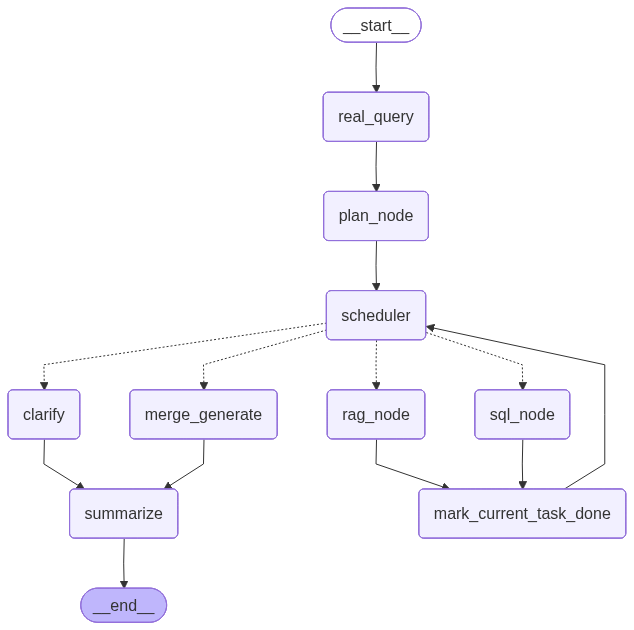

In [30]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
from pprint import pprint

def format_msg(msg):
    if isinstance(msg, dict):
        role = msg.get("role", "unknown")
        content = msg.get("content", "")
        return f"{role}: {content}"

    msg_type = getattr(msg, "type", msg.__class__.__name__)
    content = getattr(msg, "content", str(msg))

    if msg_type == "human":
        role = "user"
    elif msg_type == "ai":
        role = "assistant"
    else:
        role = msg_type

    return f"{role}: {content}"


def run_test_case(user_query: str, thread_id: str = "test1"):
    inputs = {
        "messages": [
            {
                "role": "user",
                "content": user_query,
            }
        ],
        "query": user_query,
    }

    config = {"configurable": {"thread_id": thread_id}}

    print("=" * 100)
    print(f"用户问题: {user_query}")
    print(f"thread_id: {thread_id}")
    print("=" * 100)

    for step in graph.stream(inputs, config):
        for node_name, node_output in step.items():
            print(f"\nNode: {node_name}")

            if not isinstance(node_output, dict):
                print(node_output)
                continue

            # 1. messages
            if "messages" in node_output and node_output["messages"]:
                print("messages:")
                print(format_msg(node_output["messages"][-1]))

            # 2. real_query
            if "real_query" in node_output:
                print("real_query:")
                print(node_output["real_query"])

            # 3. route / missing_slots
            if "route" in node_output:
                print("route:")
                print(node_output["route"])

            if "missing_slots" in node_output:
                print("missing_slots:")
                pprint(node_output["missing_slots"])

            # 4. task_plan
            if "task_plan" in node_output:
                print("task_plan:")
                pprint(node_output["task_plan"])

            # 5. current_task_id
            if "current_task_id" in node_output:
                print("current_task_id:")
                print(node_output["current_task_id"])

            # 6. task_results
            if "task_results" in node_output:
                print("task_results:")
                pprint(node_output["task_results"])

            # 7. execution_trace
            if "execution_trace" in node_output:
                print("execution_trace:")
                pprint(node_output["execution_trace"])

            # 8. final_answer
            if "final_answer" in node_output:
                print("final_answer:")
                print(node_output["final_answer"])

            # 9. image_path
            if "image_path" in node_output:
                print("image_path:")
                pprint(node_output["image_path"])

            # 10. summary
            if "summary" in node_output:
                print("summary:")
                print(node_output["summary"])

        print("-" * 100)

In [32]:
import ast
import json
import uuid
import pandas as pd


def parse_question_cell(cell):
    """
    解析 Excel 中“问题”列
    支持：
    1. 普通字符串
    2. JSON 字符串
    3. Python 列表字符串
    返回：问题列表，如 ["问题1", "问题2"]
    """
    if pd.isna(cell):
        return []

    if isinstance(cell, list):
        raw = cell
    else:
        text = str(cell).strip()
        if not text:
            return []

        text = (
            text.replace("“", '"')
                .replace("”", '"')
                .replace("‘", "'")
                .replace("’", "'")
        )

        if text.startswith("[") and text.endswith("]"):
            try:
                raw = json.loads(text)
            except Exception:
                raw = ast.literal_eval(text)
        else:
            return [text]

    questions = []
    for item in raw:
        if isinstance(item, dict):
            q = item.get("Q") or item.get("q") or item.get("question")
            if q and str(q).strip():
                questions.append(str(q).strip())
        elif isinstance(item, str):
            if item.strip():
                questions.append(item.strip())

    return questions


def normalize_image_list(x):
    """
    统一把 image / image_path 转成 list[str]
    """
    if x is None:
        return []
    if isinstance(x, list):
        return [str(i) for i in x if str(i).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            val = json.loads(s)
            if isinstance(val, list):
                return [str(i) for i in val if str(i).strip()]
            return [s]
        except Exception:
            return [s]
    return []


def detect_chart_type(question, image_list):
    """
    根据问题内容和是否有图，给出图形格式
    你现在先用最简单稳定的规则：
    - 没图：无
    - 有图且问题包含趋势/走势/变化：折线图
    - 有图且问题包含占比/构成：饼图
    - 其他有图：图表
    """
    if not image_list:
        return "无"

    q = str(question)
    if any(k in q for k in ["趋势", "走势", "变化", "历年", "近几年", "近年"]):
        return "折线图"
    if any(k in q for k in ["占比", "构成"]):
        return "饼图"
    if any(k in q for k in ["对比", "比较", "排名"]):
        return "柱状图"

    return "图表"

def run_one_turn(question, thread_id, turn_idx=1, question_count=1):
    """
    执行单轮问答，并提取当前轮需要写入 Excel 的核心信息
    """
    # 最后一问不做 summary；单问题也自然不做
    skip_summary = (turn_idx >= question_count)

    config = {"configurable": {"thread_id": thread_id}}
    inputs = {
        "messages": [
            {
                "role": "user",
                "content": question,
            }
        ],
        "query": question,
        "question_count": question_count,
        "skip_summary": skip_summary,
    }

    for _ in graph.stream(inputs, config):
        pass

    state = graph.get_state(config).values

#     sql_result = state.get("sql_result") or {}
#     rag_result = state.get("rag_result") or {}

#     sql_query = (
#         sql_result.get("query")
#         or sql_result.get("sql")
#         or state.get("sql_query")
#         or ""
#     )

#     answer_text = (
#         state.get("final_answer")
#         or sql_result.get("answer")
#         or rag_result.get("answer")
#         or ""
#     )

#     image_list = normalize_image_list(
#         state.get("image_path")
#         or sql_result.get("image")
#         or rag_result.get("image")
#     )
    task_results = state.get("task_results", {})

    # 1. SQL
    sql_query = state.get("last_sql_query", "")

    if not sql_query:
        for _, result in task_results.items():
            if result.get("type") == "sql" and result.get("query"):
                sql_query = result.get("query", "")

    # 2. 最终文本回答
    answer_text = state.get("final_answer", "")

    if not answer_text:
        # 如果没有 synthesis，就从最后一个任务结果里兜底取
        for _, result in task_results.items():
            if result.get("type") in ("sql", "rag", "synthesis") and result.get("answer"):
                answer_text = result.get("answer", "")

    # 3. 图表
    image_list = normalize_image_list(state.get("image_path"))

    if not image_list:
        for _, result in task_results.items():
            if result.get("type") == "sql" and result.get("image_path"):
                image_list = normalize_image_list(result.get("image_path"))
                break

    # 4. references
    references = state.get("references", [])
    if not references:
        for _, result in task_results.items():
            if result.get("type") == "rag" and result.get("references"):
                references.extend(result.get("references", []))

    answer_obj = {
        "content": answer_text
    }

    if image_list:
        answer_obj["image"] = image_list

    if references:
        answer_obj["references"] = references

    return {
        "Q": question,
        "A": answer_obj,
        "sql_query": sql_query,
        "image_list": image_list,
    }
    
    
#     answer_obj = {
#         "content": answer_text
#     }
#     if image_list:
#         answer_obj["image"] = image_list

#     return {
#         "Q": question,
#         "A": answer_obj,
#         "route": state.get("route", ""),
#         "sql_query": sql_query,
#         "image_list": image_list,
#     }

def run_excel_batch(
    xlsx_path,
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path="./result/批量问答结果.xlsx"
):
    """
    输出格式与截图一致：
    编号 | 问题 | SQL 查询语句 | 图形格式 | 回答
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    if id_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{id_col}，当前列名：{df.columns.tolist()}")
    if question_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{question_col}，当前列名：{df.columns.tolist()}")

    batch_tag = uuid.uuid4().hex[:8]
    result_rows = []

    for _, row in df.iterrows():
        row_id = str(row[id_col]).strip()
        question_list = parse_question_cell(row[question_col])

        if not question_list:
            result_rows.append({
                "编号": row_id,
                "问题": "",
                "SQL 查询语句": "",
                "图形格式": "无",
                "回答": "",
            })
            continue

        thread_id = f"excel_{batch_tag}_{row_id}"

        qa_list = []
        last_sql = ""
        final_images = []
        image_counter = 0

#         try:
#             question_count = len(question_list)

#             for turn_idx, q in enumerate(question_list, start=1):
#                 turn_result = run_one_turn(
#                     q,
#                     thread_id,
#                     turn_idx=turn_idx,
#                     question_count=question_count
#                 )

#                 qa_list.append({
#                     "Q": turn_result["Q"],
#                     "A": turn_result["A"]
#                 })

#                 # 只保留最后一次真正产生 SQL 的查询语句
#                 if turn_result["sql_query"]:
#                     last_sql = turn_result["sql_query"]

#                 # 保留最后一次有图的结果
#                 if turn_result["image_list"]:
#                     final_images = turn_result["image_list"]

#             chart_type = detect_chart_type(
#                 question=" ".join(question_list),
#                 image_list=final_images
#             )

#             result_rows.append({
#                 "编号": row_id,
#                 "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
#                 "SQL 查询语句": last_sql if last_sql else "无",
#                 "图形格式": chart_type,
#                 "回答": json.dumps(qa_list, ensure_ascii=False),
#             })
        question_count = len(question_list)

        for turn_idx, q in enumerate(question_list, start=1):
            try:
                turn_result = run_one_turn(
                    q,
                    thread_id,
                    turn_idx=turn_idx,
                    question_count=question_count
                )
                
                # ===== 新增：把当前轮生成的图片改名 =====
                renamed_images = []
                old_images = turn_result.get("image_list", [])

                for old_path in old_images:
                    if not old_path:
                        continue
                    if not os.path.exists(old_path):
                        renamed_images.append(old_path)
                        continue

                    image_counter += 1

                    ext = os.path.splitext(old_path)[1] or ".png"
                    new_path = os.path.join(
                        os.path.dirname(old_path),
                        f"{row_id}_{image_counter}{ext}"
                    )

                    # 如果目标文件已存在，先删掉，避免重命名失败
                    if os.path.exists(new_path):
                        os.remove(new_path)

                    os.replace(old_path, new_path)
                    renamed_images.append(new_path)

                # 回写 turn_result，保证后面写入 Excel 的路径也是新路径
                if renamed_images:
                    turn_result["image_list"] = renamed_images
                    if "A" in turn_result and isinstance(turn_result["A"], dict):
                        turn_result["A"]["image"] = renamed_images
        # ===== 新增结束 =====

                qa_list.append({
                    "Q": turn_result["Q"],
                    "A": turn_result["A"]
                })

                if turn_result["sql_query"]:
                    last_sql = turn_result["sql_query"]

                if turn_result["image_list"]:
                    final_images = turn_result["image_list"]

            except Exception as e:
                qa_list.append({
                    "Q": q,
                    "A": {
                        "content": f"系统异常: {str(e)}"
                    }
                })

        chart_type = detect_chart_type(
            question=" ".join(question_list),
            image_list=final_images
        )

        result_rows.append({
            "编号": row_id,
            "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
            "SQL 查询语句": last_sql if last_sql else "无",
            "图形格式": chart_type,
            "回答": json.dumps(qa_list, ensure_ascii=False, indent=2),
        })

    result_df = pd.DataFrame(result_rows)
    result_df.to_excel(output_path, index=False)
    print(f"批量问答完成，结果保存到：{output_path}")
    return result_df

In [33]:
import time

start = time.time()

result_df = run_excel_batch(
    xlsx_path=r"示例数据\附件6：问题汇总.xlsx",
    sheet_name=0,
    id_col="编号",
    question_col="问题",  
    output_path=r"示例数据\任务三批量问答结果.xlsx"
)

end = time.time()
print("运行时间：", end - start, "秒")

>>> enter plan_node
>>> before invoke
>>> after invoke
[warn] sql_db_schema 的 table_names 为空: {'name': 'sql_db_schema', 'args': {}, 'id': 'tool-dea28edfd1af44f89ea5d7359ba2473f', 'type': 'tool_call'}
>>> enter plan_node
>>> before invoke
>>> after invoke
>>> enter plan_node
>>> before invoke
>>> after invoke
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是分析华润三九近三年主营业务收入。已确认关键数据：2024年营收276.17亿元（同比增长11.6%），2025年上半年营收148.10亿元，整体呈稳健增长且具季节性特征。下一步可进行数据可视化绘图或深入分析。
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke
批量问答完成，结果保存到：示例数据\任务三批量问答结果.xlsx
运行时间： 502.00884795188904 秒


In [31]:
run_test_case("华润三九近三年的主营业务收入情况做可视化绘图", thread_id="b2003_test")
run_test_case("主营业务收入上升的原因是什么", thread_id="b2003_test")

用户问题: 华润三九近三年的主营业务收入情况做可视化绘图
thread_id: b2003_test

Node: real_query
real_query:
华润三九近三年的主营业务收入情况做可视化绘图
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke

Node: plan_node
real_query:
华润三九近三年的主营业务收入情况做可视化绘图
missing_slots:
[]
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九近三年主营业务收入时间序列数据，用于可视化绘图',
  'priority': 1,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九近三年主营业务收入时间序列数据，用于可视化绘图',
  'priority': 1,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: sql_node
messages:
assistant: 根据查询结果，我已获取到华润三九近三年主营业务收入


Node: merge_generate
messages:
assistant: 根据华润三九2025年三季报点评分析，公司主营业务收入上升主要得益于“内涵+外延”双轮驱动策略，具体原因如下：

1.  **内生业务恢复与增长**：处方药业务已较好消化了集采带来的影响，呈现逐步恢复态势；同时，内生业务在2025年第三季度实现了环比增长。
2.  **外延并购整合赋能**：公司并购整合持续推进，天士力以处方药为核心，已完成百日融合，预计将持续为公司带来赋能。
3.  **季度营收加速**：2025年前三季度公司实现营业收入219.9亿元，同比增长11.4%。特别是第三季度营收同比增长27.4%，显示出强劲的增长势头。
final_answer:
根据华润三九2025年三季报点评分析，公司主营业务收入上升主要得益于“内涵+外延”双轮驱动策略，具体原因如下：

1.  **内生业务恢复与增长**：处方药业务已较好消化了集采带来的影响，呈现逐步恢复态势；同时，内生业务在2025年第三季度实现了环比增长。
2.  **外延并购整合赋能**：公司并购整合持续推进，天士力以处方药为核心，已完成百日融合，预计将持续为公司带来赋能。
3.  **季度营收加速**：2025年前三季度公司实现营业收入219.9亿元，同比增长11.4%。特别是第三季度营收同比增长27.4%，显示出强劲的增长势头。
image_path:
[]
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标转为分析主营业务收入变动原因。已确认数据更新为：2023年63.52亿元，2024年72.94亿元，2025年前三季度219.9亿元（同比增长11.4%）。收入上升原因确认为内生业务恢复与外延并购天士力双轮驱动。历史记忆中2025年全年数据（68.54亿元）因与最新数据冲突已删除。下一步可进行数据可视化或继续深入分析。
---------

In [31]:
import time

start = time.time()

run_test_case("华润三九每股收益是多少", thread_id="test101")

end = time.time()
print("运行时间：", end - start, "秒")

用户问题: 华润三九每股收益是多少
thread_id: test101

Node: real_query
real_query:
华润三九每股收益是多少
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke

Node: plan_node
real_query:
华润三九每股收益是多少
missing_slots:
['period']
task_plan:
[{'depends_on': [],
  'goal': '向用户确认报告期，以继续查询每股收益',
  'priority': 1,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'clarify'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '向用户确认报告期，以继续查询每股收益',
  'priority': 1,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'clarify'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: clarify
messages:
assistant: 请问您想查询华润三九哪个报告期的每股收益？
missing_slots:
['period']
task_plan:
[{'depend

In [32]:
import time

start = time.time()

run_test_case("华润三九2023第一季度的每股收益是多少", thread_id="test102")

end = time.time()
print("运行时间：", end - start, "秒")

用户问题: 华润三九2023第一季度的每股收益是多少
thread_id: test102

Node: real_query
real_query:
华润三九2023第一季度的每股收益是多少
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke

Node: plan_node
real_query:
华润三九2023第一季度的每股收益是多少
missing_slots:
[]
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九2023第一季度的每股收益',
  'priority': 1,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九2023第一季度的每股收益',
  'priority': 1,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: sql_node
messages:
assistant: 根据查询结果，**华润三九2023年第一季度的每股收益为 1.16 元**。
task_results:
{

In [29]:
import time

start = time.time()

run_test_case("华润三九每股收益是多少", thread_id="test103")

end = time.time()
print("运行时间：", end - start, "秒")

run_test_case("2023第一季度的", thread_id="test103")

end1 = time.time()
print("运行时间：", end1 - end, "秒")

用户问题: 华润三九每股收益是多少
thread_id: test103

Node: real_query
real_query:
华润三九每股收益是多少
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> plan_node error: Request timed out.

Node: plan_node
real_query:
华润三九每股收益是多少
missing_slots:
['period']
task_plan:
[{'depends_on': [],
  'goal': '询问用户想查询的时间范围',
  'priority': 10,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'clarify'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '询问用户想查询的时间范围',
  'priority': 10,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'clarify'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: clarify
messages:
assistant: 请问您想查询华润三九哪个报告期的每股收益？
missing_slots:
['period']
task_pl

In [29]:
import time

start = time.time()

run_test_case("国家医保目录新增的中药产品有哪些", thread_id="test104")
run_test_case("你的依据是什么", thread_id="test104")

end = time.time()
print("运行时间：", end - start, "秒")

用户问题: 国家医保目录新增的中药产品有哪些
thread_id: test104

Node: real_query
real_query:
国家医保目录新增的中药产品有哪些
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke

Node: plan_node
real_query:
国家医保目录新增的中药产品有哪些
missing_slots:
[]
task_plan:
[{'depends_on': [],
  'goal': '检索医保目录与相关资料中新增中药产品信息',
  'priority': 1,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'rag'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '检索医保目录与相关资料中新增中药产品信息',
  'priority': 1,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'rag'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: rag_node
task_results:
{'task_1': {'docs_text': '行业点评 \n'
                         ' \n'
     


Node: merge_generate
messages:
assistant: 根据相关行业研报数据，2025年国家医保目录新增了**7个**中药产品。

具体产品及对应企业如下：

1.  **华润三九**：益气清肺颗粒（中药3.2类）。
2.  **以岭药业**：芪防鼻通片。
3.  **方盛制药**：养血祛风止痛颗粒。
4.  **康缘药业**：玉女煎颗粒、温阳解毒颗粒。

**背景补充：**
本次新增的7个产品中包含4个1类新药及3个3类新药。虽然此前通过初审的中成药有23种，但最终入选比例不高，主要系经典名方申请较多但多数未入选，且进口中药无一入选。
final_answer:
根据相关行业研报数据，2025年国家医保目录新增了**7个**中药产品。

具体产品及对应企业如下：

1.  **华润三九**：益气清肺颗粒（中药3.2类）。
2.  **以岭药业**：芪防鼻通片。
3.  **方盛制药**：养血祛风止痛颗粒。
4.  **康缘药业**：玉女煎颗粒、温阳解毒颗粒。

**背景补充：**
本次新增的7个产品中包含4个1类新药及3个3类新药。虽然此前通过初审的中成药有23种，但最终入选比例不高，主要系经典名方申请较多但多数未入选，且进口中药无一入选。
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是查询2025年国家医保目录新增中药产品。
已确认新增7个产品，涉及华润三九、以岭药业、方盛制药、康缘药业及其具体药品名称。
关键背景信息为无进口中药入选，且入选率较低。
下一步等待用户进一步指令。
----------------------------------------------------------------------------------------------------

Node: summarize
summary:
用户当前目标是查询202


Node: merge_generate
messages:
assistant: 2025年国家医保目录新增中药产品相关信息的依据主要来源于国家医保局于2025年12月7日发布的《2025新版基本医保药品目录》。具体依据及背景信息如下：

1.  **官方发布文件**：国家医保局发布的《2025新版基本医保药品目录》是直接依据，该目录将于2026年1月1日起正式执行。
2.  **政策鼓励创新导向**：本次调整明确鼓励创新方向。在通过初步审查的中成药中，最终有7个产品入选。其中，1类创新药入选比例较高（6个申请中入选4个），而申请较多的经典名方多数未入选，体现了对临床价值高的创新药的支持。
3.  **具体入选情况**：新增的7个中药产品均为独家品种，涉及华润三九、以岭药业、方盛制药、康缘药业等企业。具体产品包括益气清肺颗粒、芪防鼻通片、养血祛风止痛颗粒、玉女煎颗粒、温阳解毒颗粒等。
final_answer:
2025年国家医保目录新增中药产品相关信息的依据主要来源于国家医保局于2025年12月7日发布的《2025新版基本医保药品目录》。具体依据及背景信息如下：

1.  **官方发布文件**：国家医保局发布的《2025新版基本医保药品目录》是直接依据，该目录将于2026年1月1日起正式执行。
2.  **政策鼓励创新导向**：本次调整明确鼓励创新方向。在通过初步审查的中成药中，最终有7个产品入选。其中，1类创新药入选比例较高（6个申请中入选4个），而申请较多的经典名方多数未入选，体现了对临床价值高的创新药的支持。
3.  **具体入选情况**：新增的7个中药产品均为独家品种，涉及华润三九、以岭药业、方盛制药、康缘药业等企业。具体产品包括益气清肺颗粒、芪防鼻通片、养血祛风止痛颗粒、玉女煎颗粒、温阳解毒颗粒等。
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是查询2025年国家医保目

In [30]:
import time

start = time.time()

run_test_case("华润三九近几年的每股收益的变化趋势", thread_id="test105")

end = time.time()
print("运行时间：", end - start, "秒")

用户问题: 华润三九近几年的每股收益的变化趋势
thread_id: test105

Node: real_query
real_query:
华润三九近几年的每股收益的变化趋势
----------------------------------------------------------------------------------------------------
>>> enter plan_node
>>> before invoke
>>> after invoke

Node: plan_node
real_query:
华润三九近几年的每股收益的变化趋势
missing_slots:
[]
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九近几年的每股收益时间序列数据，用于分析变化趋势',
  'priority': 1,
  'status': 'pending',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:

task_results:
{}
execution_trace:
[]
----------------------------------------------------------------------------------------------------

Node: scheduler
task_plan:
[{'depends_on': [],
  'goal': '查询华润三九近几年的每股收益时间序列数据，用于分析变化趋势',
  'priority': 1,
  'status': 'running',
  'task_id': 'task_1',
  'type': 'sql'}]
current_task_id:
task_1
----------------------------------------------------------------------------------------------------

Node: sql_node
messages:
assistant: 根据查询结果，以下是**华润三九近几年的每股收益时间序列数据**：

| 时间周期 |